Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning (Remove corrupted images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset (ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Design CNN Architecture
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning (Optional)
        ↓
Model Evaluation
        ↓
Save Trained Model
        ↓
Inference / Prediction
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

<h4> <mark>data preprocessing 

In [ ]:
import os
from PIL import Image

In [ ]:
#now give dataset path to model 


dataset_path = r"C:\Users\shobh\Downloads\PetImages"

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

In [ ]:
#now lets count no. of individual image 

num_cats = len(os.listdir(cat_path))
num_dogs = len(os.listdir(dog_path))

print(f"Number of Cat Images : {num_cats}")
print(f"Number of Dog Images : {num_dogs}")
print(f"Total Images         : {num_cats + num_dogs}")

# analysis : 

no. of class = 2
difference of 21 images in both 

Dogs > Cats

In [ ]:
#Data Cleaning (Remove corrupted images)

import os
from PIL import Image

corrupted_images = []

for category in ["Cat", "Dog"]:
    folder = os.path.join(dataset_path, category)

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()      # Verify image integrity

        except Exception:
            corrupted_images.append(image_path)

print(f"Corrupted Images Found: {len(corrupted_images)}")

In [ ]:
# 2 image found now lets delete them 


print(corrupted_images)


for file_path in corrupted_images:os.remove(file_path)
    
print(f"Deleted: {file_path}")



#Data cleaning done now Train / Validation / Test Split



Goal of this phase : 

<b>Currently we have : 

PetImages/
├── Cat/
└── Dog/


<b> We want :

PetImages_Splitted/
│
├── train/
│   ├── Cat/
│   └── Dog/
│
├── validation/
│   ├── Cat/
│   └── Dog/
│
└── test/
    ├── Cat/
    └── Dog/

In [10]:
import os
import shutil
import random


dataset_path = r"C:\Users\shobh\Downloads\PetImages"

output_path = r"C:\Users\shobh\Downloads\PetImages_Splitted"


for split in ["train", "validation", "test"]:
    for category in ["Cat", "Dog"]:
        folder = os.path.join(output_path, split, category)
        os.makedirs(folder, exist_ok=True)


#it creates a folder structure



In [14]:
#now lets add shuffled acctuall images in al these folders using random and shutil library 

import shutil
import random

# Dataset path
dataset_path = r"C:\Users\shobh\Downloads\PetImages"

# Output path
output_path = r"C:\Users\shobh\Downloads\PetImages_Splitted"

# Split ratio
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Create folders
for split in ["train", "validation", "test"]:
    for category in ["Cat", "Dog"]:
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

# Process each category
for category in ["Cat", "Dog"]:

    category_path = os.path.join(dataset_path, category)

    # Read only image files
    images = [
        img for img in os.listdir(category_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Shuffle images
    random.shuffle(images)

    total_images = len(images)

    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy training images
    for image in train_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "train", category)
        )

    # Copy validation images
    for image in val_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "validation", category)
        )

    # Copy testing images
    for image in test_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "test", category)
        )

    print(f"{category} completed.")

print("\nDataset split completed successfully!")

Cat completed.
Dog completed.

Dataset split completed successfully!


In [15]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for category in ["Cat", "Dog"]:
        folder = os.path.join(output_path, split, category)
        print(category, ":", len(os.listdir(folder)))


TRAIN
Cat : 8743
Dog : 8728

VALIDATION
Cat : 1873
Dog : 1870

TEST
Cat : 1874
Dog : 1871


#Train / Validation / Test Split completed now next step is : Imgae Transformers


# from now on real pytorch starts till now is file handling


#we have to convert images into tensors 

Image File (.jpg)
        │
        ▼
Open Image
        │
        ▼
Resize
        │
        ▼
Convert to Tensor
        │
        ▼
Normalize
        │
        ▼
CNN

In [16]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])


# Compose() simply combines multiple transformations into one pipeline.

In [ ]:
# #synatx 

# Compose([
#     Resize(),
#     ToTensor(),
#     Normalize()
# ])

In [17]:
#till then we only created pipeline and no image has transformed yet 


from torchvision.datasets import ImageFolder


train_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\train",
    transform=transform
)

validation_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\validation",
    transform=transform
)

test_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\test",
    transform=transform
)



#verification :

print("Train Images      :", len(train_dataset))
print("Validation Images :", len(validation_dataset))
print("Test Images       :", len(test_dataset))

Train Images      : 17471
Validation Images : 3743
Test Images       : 3745


In [20]:
print(train_dataset.classes)

print(validation_dataset.classes)

print(train_dataset.class_to_idx)

['Cat', 'Dog']
['Cat', 'Dog']
{'Cat': 0, 'Dog': 1}


In [22]:
# now import dataloader so that we can send images in batches 


from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [23]:
#lets check if evbrything alright 

print(len(train_loader))
print(len(validation_loader))
print(len(test_loader))

546
117
118


In [24]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
# [32, 3, 224, 224]       batch , 3 channels(Red,Green,Blue) , height , width


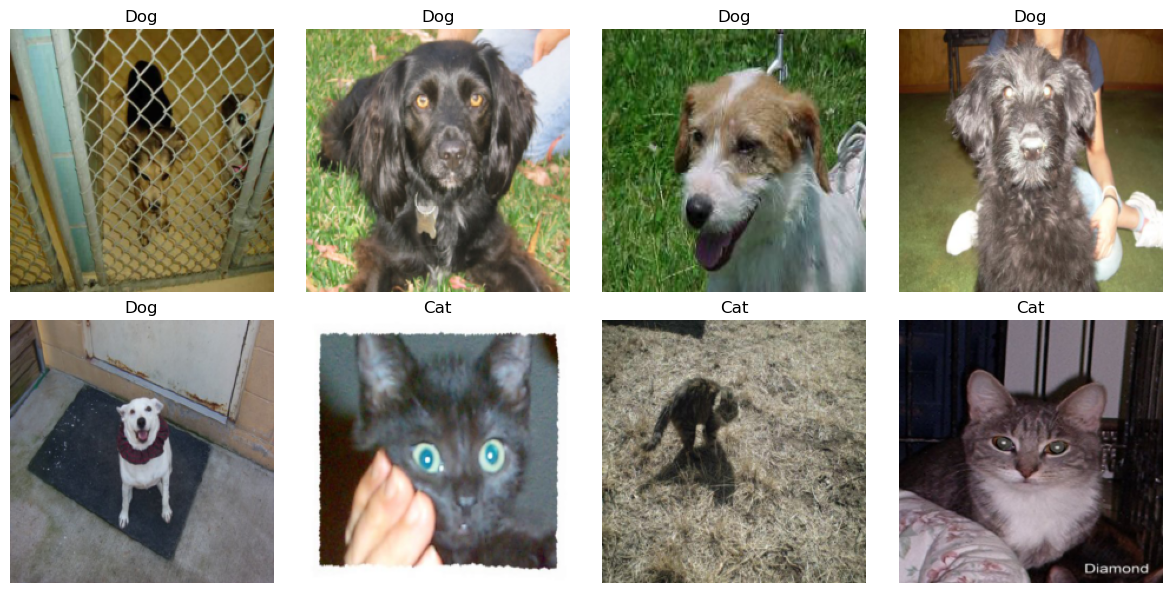

In [26]:
#lets visulaize a image to verify if evrything gonna alright then finally move to model training
import torch
import matplotlib.pyplot as plt

class_names = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i]

    # Undo normalization for display
    image = image.permute(1, 2, 0)
    image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    image = image.clamp(0, 1)

    ax.imshow(image)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning (Remove corrupted images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset (ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Design CNN Architecture
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning (Optional)
        ↓
Model Evaluation
        ↓
Save Trained Model
        ↓
Inference / Prediction
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

In [28]:
#next step : Design CNN Architecture


import torch.nn as nn

class CatDogCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3
        )

    def forward(self, x):

        x = self.conv1(x)

        return x